# Week 11 · Day 3 — The Problem with RNNs, and the LSTM Fix

Day 1 we built a SimpleRNN for sentiment — and saw it **overfit and forget**. Today we understand *why* RNNs forget, meet the **LSTM** that fixes it, and build a **next-word generator** with both so we can compare them directly.

**Today:**
1. Why RNNs forget — the vanishing-gradient problem, explained
2. The LSTM — gates and a memory cell, explained fully
3. Build a **next-word generator** (SimpleRNN)
4. Build the same generator with an **LSTM** — and compare

> **Kaggle GPU:** Settings → Accelerator → GPU.

---
# Part 1 · Why do RNNs forget?

An RNN reads a sequence one step at a time, carrying a **hidden state** (its memory). In theory that memory could hold everything. In practice, it **fades fast**.

### The core problem: vanishing gradients *through time*

- To learn, the RNN back-propagates the error **backwards through every timestep**.
- At each step the gradient gets **multiplied** by the same weights.
- Multiply a number smaller than 1 by itself many times → it shrinks toward **zero**.
- So by the time the error signal reaches the **early** words, it has essentially **vanished** — the early words barely get to influence learning.

**Result:** an RNN can link words that are *close together*, but not words that are *far apart*.

In [ ]:
# see the shrinking with your own eyes: multiply a <1 number through many steps
w = 0.6                       # a weight less than 1
signal = 1.0
print("gradient strength as it travels back through time:")
for step in range(0, 21, 4):
    print(f"  after {step:2d} timesteps: {w**step:.5f}")
print("\n-> by ~20 steps back, the signal is almost 0. The early words are 'forgotten'.")

### Why this matters for language — the long-dependency problem

Language constantly needs **long-range** memory. Andrew Ng's example:

> *"The **cat**, which already ate a big meal in the morning, **was** full."*

To choose **was** (not *were*), the model must remember **cat** (singular) — many words back. A SimpleRNN has usually forgotten "cat" by then.

More examples where early words decide a late word:
- *"I grew up in **France** … so I speak fluent ____"* → needs "France" from far back.
- *"The **keys** to the cabinet ____ on the table"* → *are* (keys), not *is* (cabinet).

> 🖼️ **IMAGE NEEDED** — search prompt: **"vanishing gradient problem RNN long term dependency diagram"**  
> *(A diagram showing an RNN unrolled over many timesteps with the gradient/arrow fading to near-zero at the early steps — visualizes why early words are forgotten.)*

---
# Part 2 · The LSTM: giving the network real memory

**LSTM = Long Short-Term Memory.** It fixes forgetting by adding a **separate memory line** — the **cell state** — that runs straight across the whole sequence, plus **gates** that control what goes on it.

### The key idea: a cell state that flows almost unchanged
- Think of the **cell state** as a conveyor belt running through the whole sequence.
- Information can ride it for many steps **without being multiplied down** — so it *doesn't* vanish.
- Small **gates** decide what to add, remove, or read from the belt at each step.

### The three gates (each is a small neural network outputting values 0–1)

At every timestep the LSTM uses three gates to manage its memory:

| Gate | Question it answers | Effect |
|---|---|---|
| **Forget gate** | "What should I erase from memory?" | multiplies the cell state by ~0 (forget) to ~1 (keep) |
| **Input gate** | "What new information should I store?" | decides which new values get **added** to the cell state |
| **Output gate** | "What should I reveal right now?" | decides what part of the memory becomes this step's hidden state |

**In plain words:** at each word the LSTM *forgets* what's no longer relevant, *stores* what's new and important, and *outputs* what's needed now — while the cell state carries long-range facts (like "cat is singular") safely forward.

### Why this beats a SimpleRNN
- The cell state gives a **gradient highway** — errors flow back across many steps without vanishing.
- The gates let the network **learn what to remember and for how long**, instead of being forced to overwrite its memory every step.

> 🖼️ **IMAGE NEEDED** — search prompt: **"LSTM cell diagram forget gate input gate output gate cell state"**  
> *(The classic LSTM cell diagram showing the cell-state line running across the top and the three gates — the central visual for this section.)*

> **A note on depth:** we're keeping the *intuition* (gates + memory belt), not deriving the equations. In code, an LSTM is a **one-line swap** for a SimpleRNN — which is exactly what we'll do next. There's also the **GRU**, a simpler cousin with two gates instead of three; `nn`-wise it's another drop-in swap.

---
# Part 3 · Build a next-word generator (SimpleRNN)

Now we put it to work on a fun task: **predict the next word.** Given some words, the model guesses what comes next — the same idea behind phone keyboard suggestions and, scaled up massively, behind ChatGPT.

**How we turn text into training data:** from each sentence we make growing "n-gram" sequences — the model sees the first *k* words and learns to predict word *k+1*.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input

tf.random.set_seed(42)
print("TF:", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.18.1 | GPUs: []


In [6]:
# a small corpus to learn from (swap in any text you like)
corpus = """
Artificial intelligence is changing the world.
Machine learning models learn patterns from data.
Deep learning uses neural networks with many layers.
A neural network learns by adjusting its weights.
Recurrent neural networks read sequences one step at a time.
An LSTM can remember information for a long time.
Natural language processing lets computers understand text.
The model predicts the next word in the sentence.
Data is the fuel of modern machine learning.
Training a model requires a lot of examples.
"""

corpus = corpus.strip().lower().split("\n")

print(corpus)
print("length of corpus : ", len(corpus))




['artificial intelligence is changing the world.', 'machine learning models learn patterns from data.', 'deep learning uses neural networks with many layers.', 'a neural network learns by adjusting its weights.', 'recurrent neural networks read sequences one step at a time.', 'an lstm can remember information for a long time.', 'natural language processing lets computers understand text.', 'the model predicts the next word in the sentence.', 'data is the fuel of modern machine learning.', 'training a model requires a lot of examples.']
length of corpus :  10


In [7]:
print(f"{len(corpus)} sentences. Example: '{corpus[0]}'")

10 sentences. Example: 'artificial intelligence is changing the world.'


In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)

print(tokenizer.word_index)
print("unique words ", len(tokenizer.word_index))

{'the': 1, 'a': 2, 'learning': 3, 'neural': 4, 'is': 5, 'machine': 6, 'data': 7, 'networks': 8, 'time': 9, 'model': 10, 'of': 11, 'artificial': 12, 'intelligence': 13, 'changing': 14, 'world': 15, 'models': 16, 'learn': 17, 'patterns': 18, 'from': 19, 'deep': 20, 'uses': 21, 'with': 22, 'many': 23, 'layers': 24, 'network': 25, 'learns': 26, 'by': 27, 'adjusting': 28, 'its': 29, 'weights': 30, 'recurrent': 31, 'read': 32, 'sequences': 33, 'one': 34, 'step': 35, 'at': 36, 'an': 37, 'lstm': 38, 'can': 39, 'remember': 40, 'information': 41, 'for': 42, 'long': 43, 'natural': 44, 'language': 45, 'processing': 46, 'lets': 47, 'computers': 48, 'understand': 49, 'text': 50, 'predicts': 51, 'next': 52, 'word': 53, 'in': 54, 'sentence': 55, 'fuel': 56, 'modern': 57, 'training': 58, 'requires': 59, 'lot': 60, 'examples': 61}
unique words  61


In [10]:
total_words = len(tokenizer.word_index) + 1   # +1 for the padding index 0
print("vocabulary size:", total_words)

vocabulary size: 62


In [14]:
[corpus[0]]

['artificial intelligence is changing the world.']

In [17]:
tokenizer.texts_to_sequences([corpus[0]])

[[12, 13, 5, 14, 1, 15]]

In [18]:
list(range(1, 6))

[1, 2, 3, 4, 5]

In [20]:
corpus[1]

'machine learning models learn patterns from data.'

In [22]:
tokenizer.texts_to_sequences([corpus[1]])[0]

[6, 3, 16, 17, 18, 19, 7]

In [23]:
# 2. build n-gram training sequences: [w1,w2], [w1,w2,w3], ...
input_sequences = []
for line in corpus:
    ids = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(ids)):
        input_sequences.append(ids[:i+1])   # a growing prefix ending at the target word

In [25]:
len(input_sequences)

70

In [28]:
max([len(line) for line in input_sequences])

10

In [29]:
max_len = max(len(s) for s in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")  # pad at the FRONT

In [30]:
input_sequences

array([[ 0,  0,  0,  0,  0,  0,  0,  0, 12, 13],
       [ 0,  0,  0,  0,  0,  0,  0, 12, 13,  5],
       [ 0,  0,  0,  0,  0,  0, 12, 13,  5, 14],
       [ 0,  0,  0,  0,  0, 12, 13,  5, 14,  1],
       [ 0,  0,  0,  0, 12, 13,  5, 14,  1, 15],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  6,  3],
       [ 0,  0,  0,  0,  0,  0,  0,  6,  3, 16],
       [ 0,  0,  0,  0,  0,  0,  6,  3, 16, 17],
       [ 0,  0,  0,  0,  0,  6,  3, 16, 17, 18],
       [ 0,  0,  0,  0,  6,  3, 16, 17, 18, 19],
       [ 0,  0,  0,  6,  3, 16, 17, 18, 19,  7],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 20,  3],
       [ 0,  0,  0,  0,  0,  0,  0, 20,  3, 21],
       [ 0,  0,  0,  0,  0,  0, 20,  3, 21,  4],
       [ 0,  0,  0,  0,  0, 20,  3, 21,  4,  8],
       [ 0,  0,  0,  0, 20,  3, 21,  4,  8, 22],
       [ 0,  0,  0, 20,  3, 21,  4,  8, 22, 23],
       [ 0,  0, 20,  3, 21,  4,  8, 22, 23, 24],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  2,  4],
       [ 0,  0,  0,  0,  0,  0,  0,  2,  4, 25],
       [ 0,  0,  0, 

In [31]:
input_sequences[:, :-1]

array([[ 0,  0,  0,  0,  0,  0,  0,  0, 12],
       [ 0,  0,  0,  0,  0,  0,  0, 12, 13],
       [ 0,  0,  0,  0,  0,  0, 12, 13,  5],
       [ 0,  0,  0,  0,  0, 12, 13,  5, 14],
       [ 0,  0,  0,  0, 12, 13,  5, 14,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  6],
       [ 0,  0,  0,  0,  0,  0,  0,  6,  3],
       [ 0,  0,  0,  0,  0,  0,  6,  3, 16],
       [ 0,  0,  0,  0,  0,  6,  3, 16, 17],
       [ 0,  0,  0,  0,  6,  3, 16, 17, 18],
       [ 0,  0,  0,  6,  3, 16, 17, 18, 19],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 20],
       [ 0,  0,  0,  0,  0,  0,  0, 20,  3],
       [ 0,  0,  0,  0,  0,  0, 20,  3, 21],
       [ 0,  0,  0,  0,  0, 20,  3, 21,  4],
       [ 0,  0,  0,  0, 20,  3, 21,  4,  8],
       [ 0,  0,  0, 20,  3, 21,  4,  8, 22],
       [ 0,  0, 20,  3, 21,  4,  8, 22, 23],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  2,  4],
       [ 0,  0,  0,  0,  0,  0,  2,  4, 25],
       [ 0,  0,  0,  0,  0,  2,  4, 25, 26],
       [ 0

In [38]:
# 3. split into inputs (all but last word) and label (the last word)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [39]:
print(len(X))
print(len(y))


70
70


In [40]:
y

array([13,  5, 14,  1, 15,  3, 16, 17, 18, 19,  7,  3, 21,  4,  8, 22, 23,
       24,  4, 25, 26, 27, 28, 29, 30,  4,  8, 32, 33, 34, 35, 36,  2,  9,
       38, 39, 40, 41, 42,  2, 43,  9, 45, 46, 47, 48, 49, 50, 10, 51,  1,
       52, 53, 54,  1, 55,  5,  1, 56, 11, 57,  6,  3,  2, 10, 59,  2, 60,
       11, 61], dtype=int32)

In [41]:

y = to_categorical(y, num_classes=total_words)   # one-hot the target word

In [43]:
y[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [44]:


print("training samples:", X.shape, " (each input is", max_len-1, "words)")
print("labels:", y.shape)

training samples: (70, 9)  (each input is 9 words)
labels: (70, 62)


### The SimpleRNN generator
Embedding → SimpleRNN → Dense(softmax over the whole vocabulary). The output is a probability for **every word** — the most likely one is the prediction.

In [46]:
rnn_model = Sequential([
    Input((max_len - 1,)),
    Embedding(total_words, 32),
    SimpleRNN(64),
    Dense(total_words, activation="softmax")
])
rnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
rnn_hist = rnn_model.fit(X, y, epochs=200)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0299 - loss: 4.1406
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1054 - loss: 4.0938
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1118 - loss: 4.0637
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1300 - loss: 4.0348 
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1300 - loss: 4.0046
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0734 - loss: 3.9727
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0552 - loss: 3.9419
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0552 - loss: 3.9168
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0552 - loss: 3.8995
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0552 - loss: 3.8866
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0741 - loss: 3.8731
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0741 - l

In [47]:
print(f"SimpleRNN final training accuracy: {rnn_hist.history['accuracy'][-1]:.2%}")

SimpleRNN final training accuracy: 100.00%


In [51]:
ids = tokenizer.texts_to_sequences(["machine learning"])

pad_ids = pad_sequences(ids, maxlen=9, padding="pre")
pad_ids

array([[0, 0, 0, 0, 0, 0, 0, 6, 3]], dtype=int32)

In [59]:
pred=rnn_model.predict(pad_ids)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


In [62]:
pred.argmax(axis=1)[0]

np.int64(16)

In [58]:
tokenizer.word_index

{'the': 1,
 'a': 2,
 'learning': 3,
 'neural': 4,
 'is': 5,
 'machine': 6,
 'data': 7,
 'networks': 8,
 'time': 9,
 'model': 10,
 'of': 11,
 'artificial': 12,
 'intelligence': 13,
 'changing': 14,
 'world': 15,
 'models': 16,
 'learn': 17,
 'patterns': 18,
 'from': 19,
 'deep': 20,
 'uses': 21,
 'with': 22,
 'many': 23,
 'layers': 24,
 'network': 25,
 'learns': 26,
 'by': 27,
 'adjusting': 28,
 'its': 29,
 'weights': 30,
 'recurrent': 31,
 'read': 32,
 'sequences': 33,
 'one': 34,
 'step': 35,
 'at': 36,
 'an': 37,
 'lstm': 38,
 'can': 39,
 'remember': 40,
 'information': 41,
 'for': 42,
 'long': 43,
 'natural': 44,
 'language': 45,
 'processing': 46,
 'lets': 47,
 'computers': 48,
 'understand': 49,
 'text': 50,
 'predicts': 51,
 'next': 52,
 'word': 53,
 'in': 54,
 'sentence': 55,
 'fuel': 56,
 'modern': 57,
 'training': 58,
 'requires': 59,
 'lot': 60,
 'examples': 61}

In [65]:
tokenizer.word_index.items()

dict_items([('the', 1), ('a', 2), ('learning', 3), ('neural', 4), ('is', 5), ('machine', 6), ('data', 7), ('networks', 8), ('time', 9), ('model', 10), ('of', 11), ('artificial', 12), ('intelligence', 13), ('changing', 14), ('world', 15), ('models', 16), ('learn', 17), ('patterns', 18), ('from', 19), ('deep', 20), ('uses', 21), ('with', 22), ('many', 23), ('layers', 24), ('network', 25), ('learns', 26), ('by', 27), ('adjusting', 28), ('its', 29), ('weights', 30), ('recurrent', 31), ('read', 32), ('sequences', 33), ('one', 34), ('step', 35), ('at', 36), ('an', 37), ('lstm', 38), ('can', 39), ('remember', 40), ('information', 41), ('for', 42), ('long', 43), ('natural', 44), ('language', 45), ('processing', 46), ('lets', 47), ('computers', 48), ('understand', 49), ('text', 50), ('predicts', 51), ('next', 52), ('word', 53), ('in', 54), ('sentence', 55), ('fuel', 56), ('modern', 57), ('training', 58), ('requires', 59), ('lot', 60), ('examples', 61)])

In [74]:
# a helper that generates text word-by-word from a seed
def generate_text(model, seed, n_words):
    result = seed
    for _ in range(n_words):
        ids = tokenizer.texts_to_sequences([result])[0]
        ids = pad_sequences([ids], maxlen=max_len - 1, padding="pre")
        pred_id = model.predict(ids, verbose=0).argmax(axis=1)[0]
        word = next((w for w, i in tokenizer.word_index.items() if i == pred_id), "")
        result += " " + word
    return result

for seed in ["machine learning", "a neural", "the model"]:
    print("RNN:", generate_text(rnn_model, seed, 5))

RNN: machine learning models learn patterns from data
RNN: a neural network learns by adjusting its
RNN: the model predicts the next word in


In [72]:
[w for w, i in tokenizer.word_index.items() if i==16][0]

'models'

In [75]:
corpus

['artificial intelligence is changing the world.',
 'machine learning models learn patterns from data.',
 'deep learning uses neural networks with many layers.',
 'a neural network learns by adjusting its weights.',
 'recurrent neural networks read sequences one step at a time.',
 'an lstm can remember information for a long time.',
 'natural language processing lets computers understand text.',
 'the model predicts the next word in the sentence.',
 'data is the fuel of modern machine learning.',
 'training a model requires a lot of examples.']

In [77]:
generate_text(rnn_model, "natural", 9)

'natural language processing lets computers understand text machine learning models'

---
# Part 4 · The same generator with an LSTM

Here's the payoff of Part 2: to use an LSTM instead of a SimpleRNN, we change **one line** — `SimpleRNN(64)` → `LSTM(64)`. Everything else is identical. Then we compare.

In [78]:
lstm_model = Sequential([
    Input((max_len - 1,)),
    Embedding(total_words, 32),
    LSTM(64),                       # <-- the ONLY change from the RNN model
    Dense(total_words, activation="softmax")
])
lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
lstm_hist = lstm_model.fit(X, y, epochs=200)


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.0189 - loss: 4.1280
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1164 - loss: 4.1217
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1157 - loss: 4.1170
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1268 - loss: 4.1119
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1339 - loss: 4.1057
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1151 - loss: 4.0978
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1151 - loss: 4.0871
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1008 - loss: 4.0721
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0709 - loss: 4.0510 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0598 - loss: 4.0242
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0598 - loss: 4.0014
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1079 - lo

In [79]:
print(f"LSTM final training accuracy: {lstm_hist.history['accuracy'][-1]:.2%}")

LSTM final training accuracy: 97.14%


In [80]:
for seed in ["machine learning", "a neural", "the model"]:
    print("LSTM:", generate_text(lstm_model, seed, 5))

LSTM: machine learning models learn patterns from data
LSTM: a neural network learns by adjusting its
LSTM: the model predicts the next word in


### Compare the two

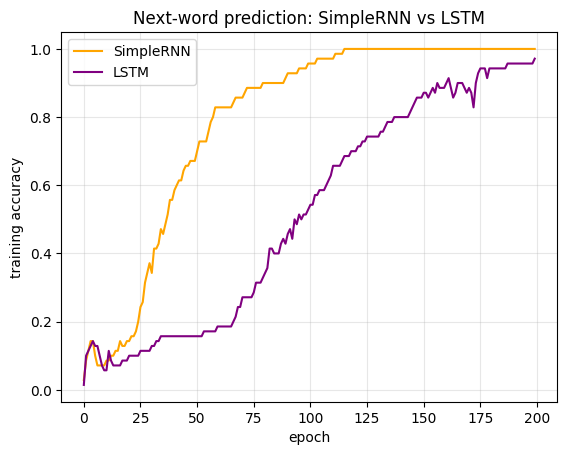

SimpleRNN: 100.00%
LSTM:      97.14%


In [81]:
import matplotlib.pyplot as plt

plt.plot(rnn_hist.history["accuracy"], label="SimpleRNN", color="orange")
plt.plot(lstm_hist.history["accuracy"], label="LSTM", color="purple")
plt.xlabel("epoch"); 
plt.ylabel("training accuracy")
plt.title("Next-word prediction: SimpleRNN vs LSTM")
plt.legend(); 
plt.grid(alpha=0.3); 
plt.show()

print(f"SimpleRNN: {rnn_hist.history['accuracy'][-1]:.2%}")
print(f"LSTM:      {lstm_hist.history['accuracy'][-1]:.2%}")

**What to look for:** this corpus is *tiny*, so **both models can memorize it** — and a SimpleRNN may even match the LSTM here. That's expected, and it's an honest lesson: the LSTM's advantage only shows up when sequences are **long enough that forgetting matters**.

- On short, memorizable text: RNN ≈ LSTM.
- On long, real text (paragraphs, articles): the SimpleRNN forgets early context and its output drifts, while the **LSTM keeps the thread** — the gap widens with length.

> The takeaway isn't "LSTM wins this toy demo" — it's that the LSTM's gated memory *removes the forgetting ceiling* we diagnosed in Part 1, with a one-line change. Try the solo task with a longer corpus to feel the difference.

---
## Your turn (solo task) ✍️

Pick at least two:
1. **Feed it your own corpus** — paste 10–20 sentences (song lyrics, news, your notes) into `corpus` and see what it generates.
2. **Swap in a GRU** (`from tensorflow.keras.layers import GRU`, then `GRU(64)`) — compare it to the RNN and LSTM.
3. **Stack two LSTMs** (first one needs `return_sequences=True`) — does deeper help?
4. **Train longer** (400 epochs) and generate longer text — where does each model start repeating itself?
5. **Try different seeds** — which continuations make sense, which don't?

In [ ]:
# ===== YOUR EXPERIMENTS HERE =====



---
## Summary

- **Why RNNs forget:** gradients are multiplied at every timestep and **vanish** over long sequences — so early words can't influence far-away predictions (the long-dependency problem).
- **The LSTM fix:** a **cell state** (a memory "conveyor belt") that carries information across many steps without vanishing, controlled by three **gates**:
  - **forget** (erase the irrelevant), **input** (store the new), **output** (reveal what's needed now).
- **Next-word generation:** turn text into n-gram sequences, predict the next word from the previous ones — the core idea behind autocomplete and LLMs.
- **RNN → LSTM is a one-line change**, and the LSTM handles context better. (**GRU** is the simpler two-gate cousin.)

**Next:** word embeddings in depth (Word2Vec/GloVe), then attention and Transformers — continuing Andrew Ng's Sequence Models.